# Sanity Check - Step 05: Bandpass Filter (1-40 Hz)

Überprüft:
- Filter erfolgreich angewendet
- Frequenzband korrekt (1-40 Hz)
- Power Spectral Density vor/nach Vergleich
- Amplituden reduziert

In [1]:
import os
import sys
from pathlib import Path
import mne
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd()
candidate_roots = [root, root.parent, root.parent.parent]
for candidate in candidate_roots:
    pipeline_dir = candidate / "eeg_pipeline"
    if pipeline_dir.exists() and str(pipeline_dir) not in sys.path:
        sys.path.insert(0, str(pipeline_dir))
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

try:
    from eeg_pipeline import config
except ModuleNotFoundError:
    import config

print("Setup erfolgreich")

Setup erfolgreich


In [ ]:
# Manuelle Auswahl fuer diesen Notebook-Run
subject_id = "01"  # z.B. "02"
person = "P1"  # "P1" oder "P2"
if person not in {"P1", "P2"}:
    raise ValueError("person muss P1 oder P2 sein")
os.environ["EEG_SUBJECT"] = subject_id
os.environ["EEG_PERSON"] = person
print(f"Manuell gesetzt: EEG_SUBJECT={os.environ['EEG_SUBJECT']}, EEG_PERSON={os.environ['EEG_PERSON']}")

## 1. Before & After laden

In [2]:
subject_id = os.getenv("EEG_SUBJECT", config.SUBJECTS[0]).strip()
person = os.getenv("EEG_PERSON", "P1").strip().upper()
if person not in {"P1", "P2"}:
    raise ValueError("EEG_PERSON muss P1 oder P2 sein")

before_path = config.OUTPUT_DIR / f"sub-{subject_id}_{person}_interpolated.fif"
after_path = config.OUTPUT_DIR / f"sub-{subject_id}_{person}_filtered.fif"

if before_path.exists() and after_path.exists():
    raw_before = mne.io.read_raw_fif(str(before_path), preload=False)
    raw_after = mne.io.read_raw_fif(str(after_path), preload=False)
    print(f"✓ Both files loaded for {person}")
else:
    print("✗ Files not found")

Opening raw data file c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P1_interpolated.fif...
    Range : 0 ... 733799 =      0.000 ...  3668.995 secs
Ready.
Opening raw data file c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P1_filtered.fif...
    Range : 0 ... 733799 =      0.000 ...  3668.995 secs
Ready.
✓ Both files loaded for P1


C:\Users\BKALYON\AppData\Local\Temp\ipykernel_22112\696651146.py:10: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P1_interpolated.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_before = mne.io.read_raw_fif(str(before_path), preload=False)
C:\Users\BKALYON\AppData\Local\Temp\ipykernel_22112\696651146.py:11: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P1_filtered.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_after = mne.io.read_raw_fif(str(after_path), preload=False)


## 2. Metadata Überprüfung

In [3]:
print(f"=== VORHER ===")
print(f"Sampling rate: {raw_before.info['sfreq']} Hz")
print(f"Kanäle: {len(raw_before.ch_names)}")
print(f"Dauer: {raw_before.times[-1]:.2f}s")

print(f"\n=== NACHHER (gefiltert) ===")
print(f"Sampling rate: {raw_after.info['sfreq']} Hz")
print(f"Kanäle: {len(raw_after.ch_names)}")
print(f"Dauer: {raw_after.times[-1]:.2f}s")

print(f"\n=== VALIDIERUNGEN ===")
if len(raw_before.ch_names) == len(raw_after.ch_names):
    print(f"✓ Kanal-Anzahl erhalten")
if raw_before.info['sfreq'] == raw_after.info['sfreq']:
    print(f"✓ Sampling rate erhalten")
if raw_before.n_times == raw_after.n_times:
    print(f"✓ Sample-Anzahl erhalten")

=== VORHER ===
Sampling rate: 200.0 Hz
Kanäle: 72
Dauer: 3668.99s

=== NACHHER (gefiltert) ===
Sampling rate: 200.0 Hz
Kanäle: 72
Dauer: 3668.99s

=== VALIDIERUNGEN ===
✓ Kanal-Anzahl erhalten
✓ Sampling rate erhalten
✓ Sample-Anzahl erhalten


## 3. Amplituden-Vergleich

In [4]:
eeg_picks = mne.pick_types(raw_before.info, eeg=True)

# Get small sample for comparison
t_end = min(60, raw_before.times[-1])
t_idx_end = int(t_end * raw_before.info['sfreq'])

data_before = raw_before.get_data(picks=eeg_picks[0:1], start=0, stop=t_idx_end)
data_after = raw_after.get_data(picks=eeg_picks[0:1], start=0, stop=t_idx_end)

std_before = np.std(data_before)
std_after = np.std(data_after)
reduction = (1 - std_after/std_before) * 100

print(f"Amplituden (erstes EEG-Kanal, erste 60s):")
print(f"  VORHER: {std_before:.6f} µV (Std)")
print(f"  NACHHER: {std_after:.6f} µV (Std)")
print(f"  Reduktion: {reduction:.1f}%")

Amplituden (erstes EEG-Kanal, erste 60s):
  VORHER: 0.000088 µV (Std)
  NACHHER: 0.000038 µV (Std)
  Reduktion: 56.6%


## 4. PSD Vergleich

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 10.240 (s)
Plotting power spectral density (dB=True).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 10.240 (s)
Plotting power spectral density (dB=True).


C:\Users\BKALYON\AppData\Local\Temp\ipykernel_22112\1172352801.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


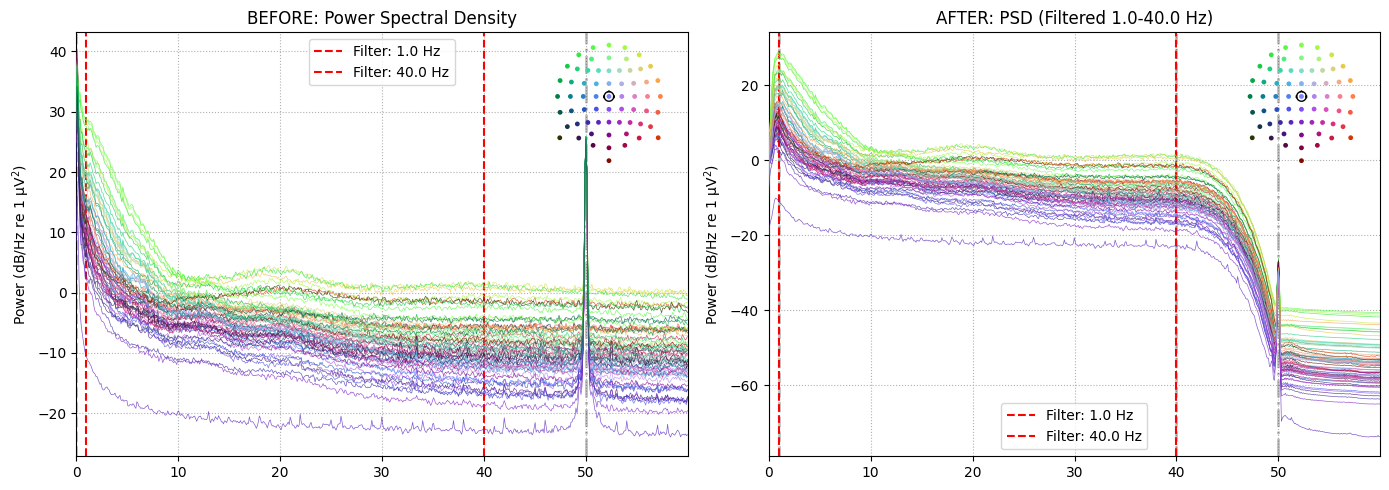

✓ PSD plot saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VORHER
raw_before_eeg = raw_before.copy().pick_types(eeg=True)
raw_before_eeg.plot_psd(fmax=60, ax=axes[0], show=False)
axes[0].axvline(x=config.FREQ_LOWER, color='red', linestyle='--', label=f'Filter: {config.FREQ_LOWER} Hz')
axes[0].axvline(x=config.FREQ_UPPER, color='red', linestyle='--', label=f'Filter: {config.FREQ_UPPER} Hz')
axes[0].set_title('BEFORE: Power Spectral Density')
axes[0].legend()

# NACHHER
raw_after_eeg = raw_after.copy().pick_types(eeg=True)
raw_after_eeg.plot_psd(fmax=60, ax=axes[1], show=False)
axes[1].axvline(x=config.FREQ_LOWER, color='red', linestyle='--', label=f'Filter: {config.FREQ_LOWER} Hz')
axes[1].axvline(x=config.FREQ_UPPER, color='red', linestyle='--', label=f'Filter: {config.FREQ_UPPER} Hz')
axes[1].set_title(f'AFTER: PSD (Filtered {config.FREQ_LOWER}-{config.FREQ_UPPER} Hz)')
axes[1].legend()

plt.tight_layout()
plt.savefig(config.QC_DIR / f'sub-{subject_id}_{person}_filter_psd_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ PSD plot saved")